# shooting optimal control pendulum w/ autodiff

In [1]:
import matplotlib.pyplot as plt
from trexdiff import Node, sin, cos, log, tensor2d
import numpy as np
import matplotlib

In [30]:
g = Node(tensor2d([[9.81]]))
dt = Node(tensor2d([[5e-2]]))
p5 = Node(tensor2d([[0.5]]))

T = 10

x0 = [
    Node(tensor2d([[0.0]])), # theta
    Node(tensor2d([[0.0]])), # theta_dot
]

# m = tensor2d([[1.0]])
# l = tensor2d([[1.0]])

def f(x, dx, u, dt):
    # pendulum forward dynamics
    # we don't support indexing, so have to use masks
    # x - theta, dx - theta_dot
    
    theta_ddot = u - g @ sin(x)

    # implicit Euler
    x_new = x + dx @ dt + p5 @ theta_ddot @ dt @ dt
    dx_new = dx + theta_ddot @ dt
    return x_new, dx_new

xs = [x0]
us = []
for i in range(T):
    u = Node(tensor2d([[0.0]]))
    us.append(u)

    x_new, dx_new = f(xs[-1][0], xs[-1][1], u, dt)
    xs.append((x_new, dx_new))


In [31]:
# loss is squared distance to upright position at final time step
target = Node(tensor2d([[np.pi]]))
Qf = Node(tensor2d([[1e5]]))

loss = Qf @ (xs[-1][0] - target) @ (xs[-1][0] - target) + Qf @ (xs[-1][1] @ xs[-1][1])


In [32]:
# gradient descent over the control inputs
learning_rate = 2.5e-4

for i in range(500):
    loss.zerograd()
    loss.forward()
    loss.backward()

    if i % 10 == 0:
        print(f"iter {i}, loss {loss.val[0,0]:.3f}")

    for u in us:
        u.val -= learning_rate * u.grad

iter 0, loss 986960.440
iter 10, loss 466695.078
iter 20, loss 262109.035
iter 30, loss 161273.910
iter 40, loss 104852.180
iter 50, loss 70547.710
iter 60, loss 48546.405
iter 70, loss 33925.932
iter 80, loss 23969.896
iter 90, loss 17071.649
iter 100, loss 12231.457
iter 110, loss 8803.421
iter 120, loss 6358.357
iter 130, loss 4604.962
iter 140, loss 3342.302
iter 150, loss 2430.044
iter 160, loss 1769.233
iter 170, loss 1289.569
iter 180, loss 940.812
iter 190, loss 686.892
iter 200, loss 501.816
iter 210, loss 366.796
iter 220, loss 268.221
iter 230, loss 196.207
iter 240, loss 143.572
iter 250, loss 105.083
iter 260, loss 76.929
iter 270, loss 56.328
iter 280, loss 41.250
iter 290, loss 30.212
iter 300, loss 22.131
iter 310, loss 16.212
iter 320, loss 11.877
iter 330, loss 8.702
iter 340, loss 6.376
iter 350, loss 4.672
iter 360, loss 3.424
iter 370, loss 2.509
iter 380, loss 1.839
iter 390, loss 1.347
iter 400, loss 0.987
iter 410, loss 0.724
iter 420, loss 0.530
iter 430, loss 

Text(0.5, 1.0, 'Control input over time')

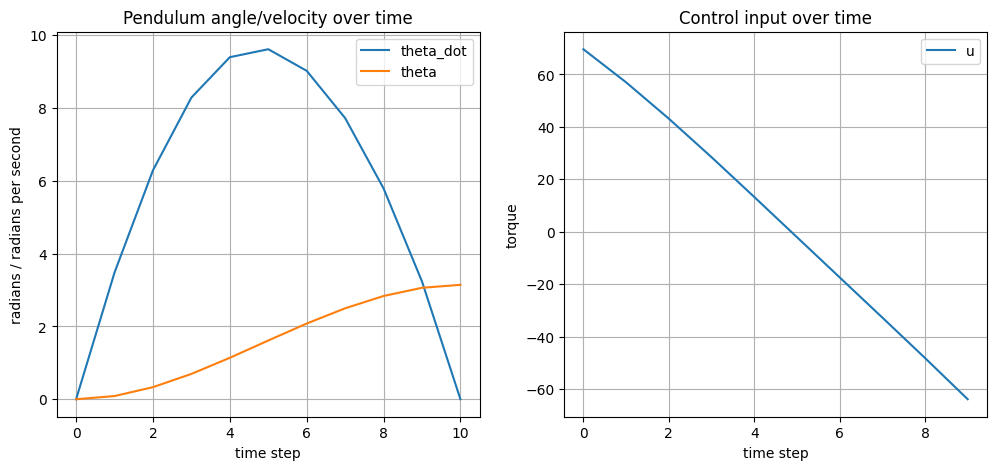

In [49]:
plt.subplots(1,2, figsize=(12,5))

# plot x, x_dot
thetas = [x[0].val[0,0] for x in xs]
theta_dots = [x[1].val[0,0] for x in xs]

plt.subplot(1,2,1)

plt.plot(theta_dots, label="theta_dot")
plt.plot(thetas, label="theta")

plt.xlabel("time step")
plt.ylabel("radians / radians per second")
plt.grid()
plt.legend()
plt.title("Pendulum angle/velocity over time")

# plot control inputs
plt.subplot(1,2,2)
us = [u.val[0,0] for u in us]
plt.plot(us, label="u")
plt.xlabel("time step")
plt.ylabel("torque")
plt.grid()
plt.legend()
plt.title("Control input over time")
